In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/Global_Oral.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted at:", extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted at: /content/data


In [ ]:
import os, json, torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
data_dir = "/content/data"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_data   = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=transform)
test_data  = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16)
test_loader  = DataLoader(test_data, batch_size=16)

print("Classes:", train_data.classes)

Classes: ['Cancer', 'Control']


In [ ]:
class HF_UNet(nn.Module):
    def __init__(self):
        super(HF_UNet, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*224*224, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HF_UNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

SAVE_DIR = "/content/drive/MyDrive/HF_UNET_SAVE/"
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint_path = SAVE_DIR + "checkpoint.pth"
history_path = SAVE_DIR + "history.json"

In [ ]:
start_epoch = 0
history = {"loss": [], "accuracy": []}

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_epoch = checkpoint['epoch'] + 1
    print("Resuming from epoch", start_epoch)

if os.path.exists(history_path):
    with open(history_path, "r") as f:
        history = json.load(f)

Resuming from epoch 4


In [ ]:
EPOCHS = 20

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # SAVE MODEL
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }, checkpoint_path)

    # SAVE HISTORY
    with open(history_path, "w") as f:
        json.dump(history, f)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 5/20 | Loss: 0.3122 | Acc: 0.8658
Epoch 6/20 | Loss: 0.2310 | Acc: 0.9075
Epoch 7/20 | Loss: 0.1643 | Acc: 0.9398
Epoch 8/20 | Loss: 0.1140 | Acc: 0.9571
Epoch 9/20 | Loss: 0.1059 | Acc: 0.9619
Epoch 10/20 | Loss: 0.0452 | Acc: 0.9870
Epoch 11/20 | Loss: 0.0307 | Acc: 0.9930
Epoch 12/20 | Loss: 0.0347 | Acc: 0.9903
Epoch 13/20 | Loss: 0.0148 | Acc: 0.9964
Epoch 14/20 | Loss: 0.0426 | Acc: 0.9909
Epoch 15/20 | Loss: 0.0447 | Acc: 0.9888
Epoch 16/20 | Loss: 0.0203 | Acc: 0.9952
Epoch 17/20 | Loss: 0.0229 | Acc: 0.9937
Epoch 18/20 | Loss: 0.0465 | Acc: 0.9879
Epoch 19/20 | Loss: 0.0081 | Acc: 0.9988
Epoch 20/20 | Loss: 0.0056 | Acc: 0.9988


In [ ]:
import json

history_path = "/content/drive/MyDrive/HF_UNET_SAVE/history.json"

with open(history_path, "r") as f:
    history = json.load(f)

total_epochs = len(history["loss"])

for i in range(total_epochs):
    print(f"Epoch {i+1}: Loss = {history['loss'][i]:.4f}, Acc = {history['accuracy'][i]:.4f}")

Epoch 1: Loss = 0.9148, Acc = 0.6236
Epoch 2: Loss = 0.5493, Acc = 0.7291
Epoch 3: Loss = 0.4833, Acc = 0.7678
Epoch 4: Loss = 0.4035, Acc = 0.8210
Epoch 5: Loss = 0.3122, Acc = 0.8658
Epoch 6: Loss = 0.2310, Acc = 0.9075
Epoch 7: Loss = 0.1643, Acc = 0.9398
Epoch 8: Loss = 0.1140, Acc = 0.9571
Epoch 9: Loss = 0.1059, Acc = 0.9619
Epoch 10: Loss = 0.0452, Acc = 0.9870
Epoch 11: Loss = 0.0307, Acc = 0.9930
Epoch 12: Loss = 0.0347, Acc = 0.9903
Epoch 13: Loss = 0.0148, Acc = 0.9964
Epoch 14: Loss = 0.0426, Acc = 0.9909
Epoch 15: Loss = 0.0447, Acc = 0.9888
Epoch 16: Loss = 0.0203, Acc = 0.9952
Epoch 17: Loss = 0.0229, Acc = 0.9937
Epoch 18: Loss = 0.0465, Acc = 0.9879
Epoch 19: Loss = 0.0081, Acc = 0.9988
Epoch 20: Loss = 0.0056, Acc = 0.9988


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import json

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/HF_UNET_SAVE/checkpoint.pth")
model.load_state_dict(checkpoint['model'])
model.eval()

HF_UNet(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=802816, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
def evaluate(loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [ ]:
y_true_test, y_pred_test = evaluate(test_loader)
y_true_val, y_pred_val = evaluate(val_loader)

In [ ]:
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    specificity = TN / (TN + FP)

    return acc, precision, recall, specificity, f1, cm

In [ ]:
acc, precision, recall, specificity, f1, cm = get_metrics(y_true_test, y_pred_test)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)

Accuracy: 0.855072463768116
Precision: 0.8154506437768241
Recall (Sensitivity): 0.9178743961352657
Specificity: 0.7922705314009661
F1 Score: 0.8636363636363636


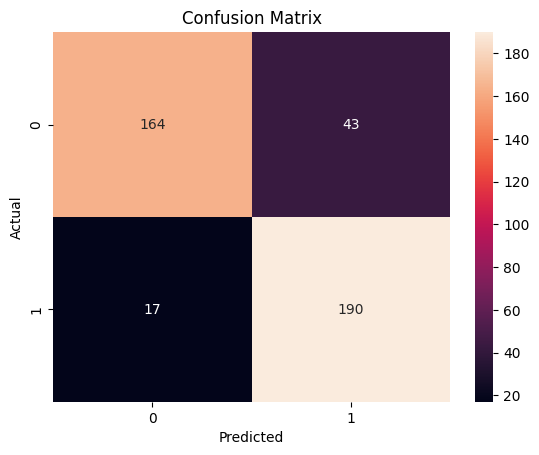

In [ ]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("/content/drive/MyDrive/HF_UNET_SAVE/confusion_matrix.png")
plt.show()

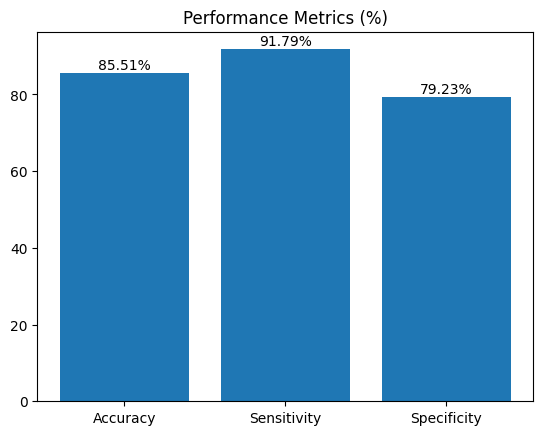

In [ ]:
metrics = [acc*100, recall*100, specificity*100]
labels = ["Accuracy", "Sensitivity", "Specificity"]

plt.figure()
bars = plt.bar(labels, metrics)

for i, v in enumerate(metrics):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.title("Performance Metrics (%)")
plt.savefig("/content/drive/MyDrive/HF_UNET_SAVE/metrics_bar.png")
plt.show()

In [ ]:
with open("/content/drive/MyDrive/HF_UNET_SAVE/history.json", "r") as f:
    history = json.load(f)

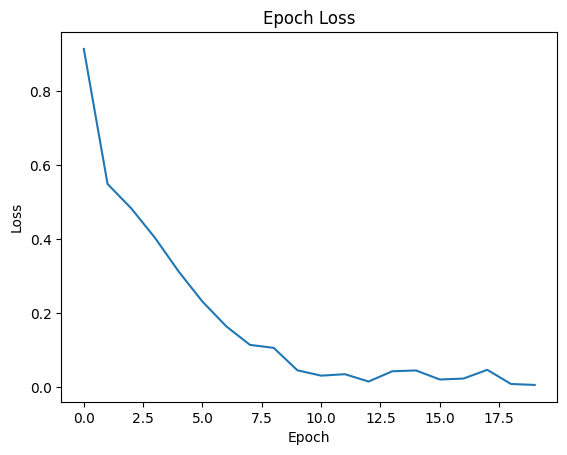

In [ ]:
plt.figure()
plt.plot(history["loss"])
plt.title("Epoch Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("/content/drive/MyDrive/HF_UNET_SAVE/loss.png")
plt.show()

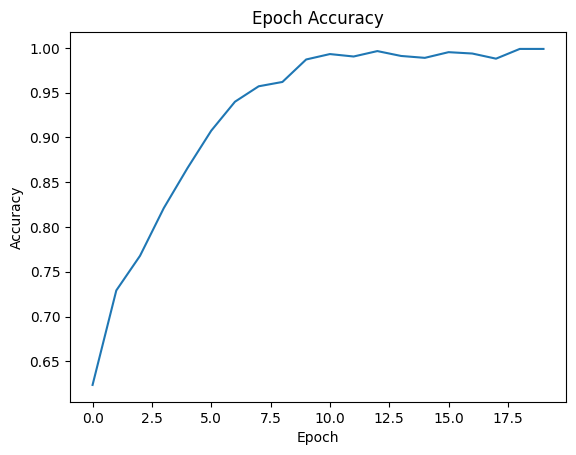

In [ ]:
plt.figure()
plt.plot(history["accuracy"])
plt.title("Epoch Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("/content/drive/MyDrive/HF_UNET_SAVE/accuracy.png")
plt.show()

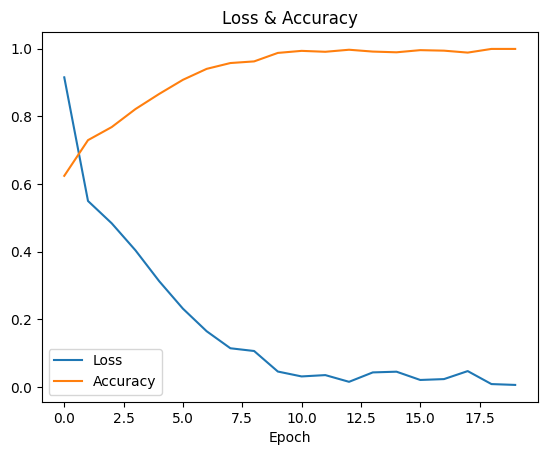

In [ ]:
plt.figure()
plt.plot(history["loss"], label="Loss")
plt.plot(history["accuracy"], label="Accuracy")
plt.legend()
plt.title("Loss & Accuracy")
plt.xlabel("Epoch")
plt.savefig("/content/drive/MyDrive/HF_UNET_SAVE/loss_acc.png")
plt.show()

In [ ]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ---------- SAVE DIR ----------
SAVE_DIR = "/content/drive/MyDrive/HF_UNET_FINAL/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. SAVE FINAL MODEL ----------
torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict()
}, SAVE_DIR + "final_model.pth")

# ---------- 2. LOAD HISTORY ----------
with open("/content/drive/MyDrive/HF_UNET_SAVE/history.json", "r") as f:
    history = json.load(f)

# ---------- 3. GET PREDICTIONS ----------
def get_preds(loader):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# TEST SET
y_true, y_pred = get_preds(test_loader)

# ---------- 4. METRICS ----------
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)

metrics = {
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "specificity": specificity,
    "f1_score": f1
}

# SAVE METRICS JSON
with open(SAVE_DIR + "final_metrics.json", "w") as f:
    json.dump(metrics, f)

print(metrics)

# ---------- 5. CONFUSION MATRIX IMAGE ----------
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig(SAVE_DIR + "confusion_matrix.png")
plt.close()

# ---------- 6. BAR GRAPH ----------
plt.figure()
plt.bar(["Accuracy","Sensitivity","Specificity"], [acc*100, recall*100, specificity*100])

for i, v in enumerate([acc*100, recall*100, specificity*100]):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')

plt.title("Metrics (%)")
plt.savefig(SAVE_DIR + "metrics_bar.png")
plt.close()

# ---------- 7. TRAINING GRAPHS ----------
loss = history["loss"]
accuracy = history["accuracy"]

# Loss
plt.figure()
plt.plot(loss)
plt.title("Epoch Loss")
plt.savefig(SAVE_DIR + "loss.png")
plt.close()

# Accuracy
plt.figure()
plt.plot(accuracy)
plt.title("Epoch Accuracy")
plt.savefig(SAVE_DIR + "accuracy.png")
plt.close()

# Combined
plt.figure()
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy")
plt.legend()
plt.title("Loss vs Accuracy")
plt.savefig(SAVE_DIR + "combined.png")
plt.close()

# ---------- 8. SAVE PREDICTIONS ----------
np.save(SAVE_DIR + "y_true.npy", y_true)
np.save(SAVE_DIR + "y_pred.npy", y_pred)

print("🔥 HF-UNET EVERYTHING SAVED SUCCESSFULLY")

{'accuracy': 0.855072463768116, 'precision': 0.8154506437768241, 'recall': 0.9178743961352657, 'specificity': np.float64(0.7922705314009661), 'f1_score': 0.8636363636363636}
🔥 HF-UNET EVERYTHING SAVED SUCCESSFULLY
